In [18]:
import numpy as np
import bayesflow as bf
import keras
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import pickle
from benchmark.examples.gaussian.approximators.simulator import Simulator    
from benchmark.examples.gaussian.approximators.approximators import BayesFLowNPE 
from benchmark.examples.gaussian.datasets.stan_dataset import  StanDataset
from benchmark.examples.gaussian.datasets.calculation import Calculation
from benchmark.examples.gaussian.datasets.analysis import Analysis

In [19]:
RNG=np.random.default_rng(2025)
mu_prior_mean=10
mu_prior_std=1
num_dims=5
num_obs=100
likelihood_std=1

In [31]:
simulator_bayes=Simulator(mu_prior_mean=mu_prior_mean, mu_prior_std=mu_prior_std, 
                          num_dims=num_dims, num_obs=num_obs,
                          likelihood_std=likelihood_std,rng=RNG)
simulator=simulator_bayes.get_bayes_simulator()
bayesflownpe=BayesFLowNPE(simulator=simulator)
bayesflownpe._build_workflow()
history=bayesflownpe.train(epochs=100,batch_size=64,num_batches_per_epoch=200)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 19s 58ms/step - loss: 15.1981
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step - loss: 7.3977
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - loss: 6.5595
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - loss: 6.1713
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step - loss: 5.5814
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step - loss: 5.1042
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - loss: 4.6444
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - loss: 4.2249
Epoch 9/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - loss: 4.1579
Epoch 10/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - loss: 3.8361
Epoch 11/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - loss: 3.5505
Epoch 12/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - loss: 3.5608
Epoch 13/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - loss: 3.0725
Epoch 14/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step - loss: 3.0762
Epoch 15/100
2

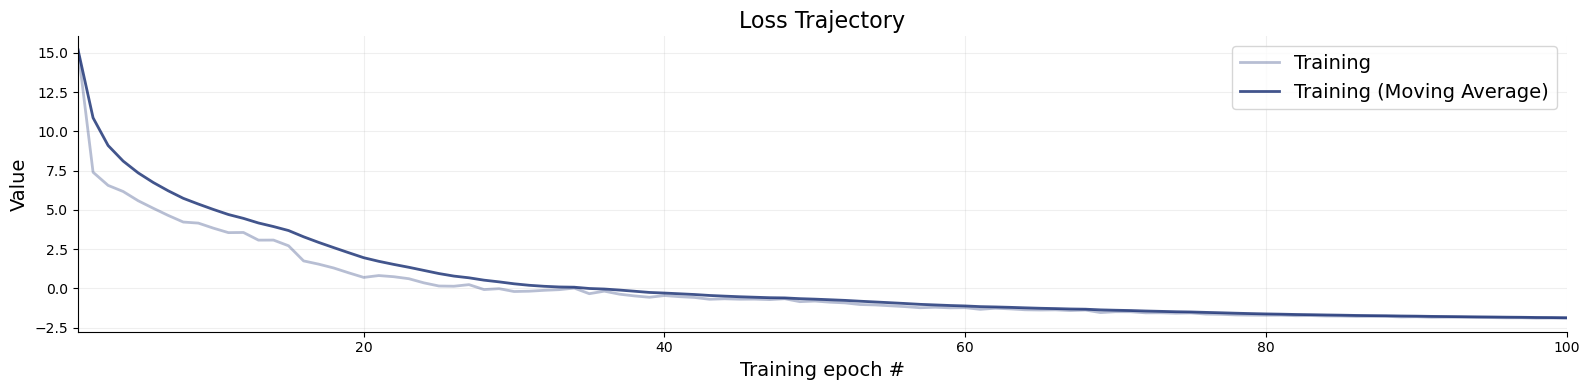

In [32]:
f=bf.diagnostics.plots.loss(history)

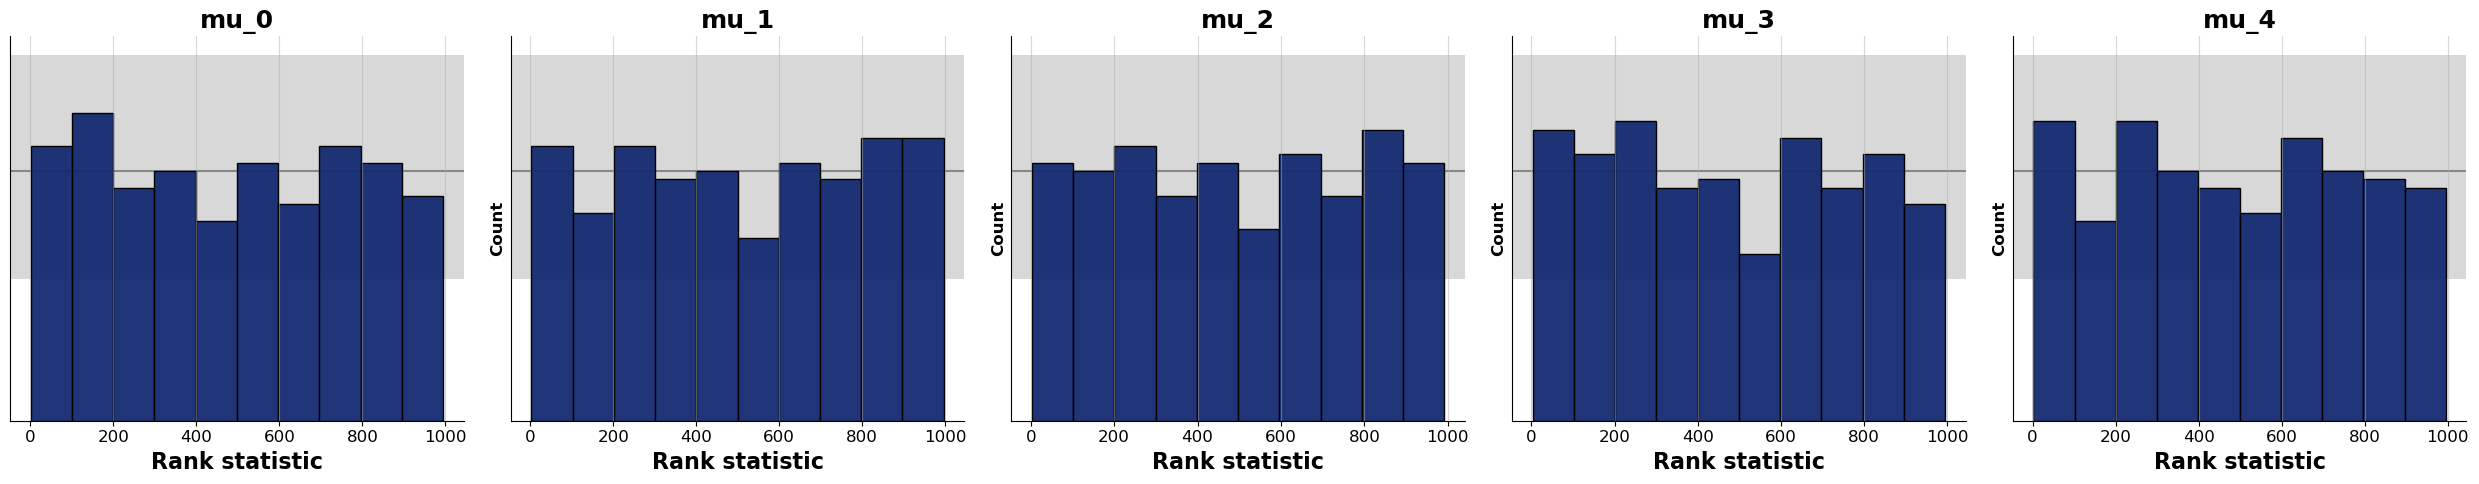

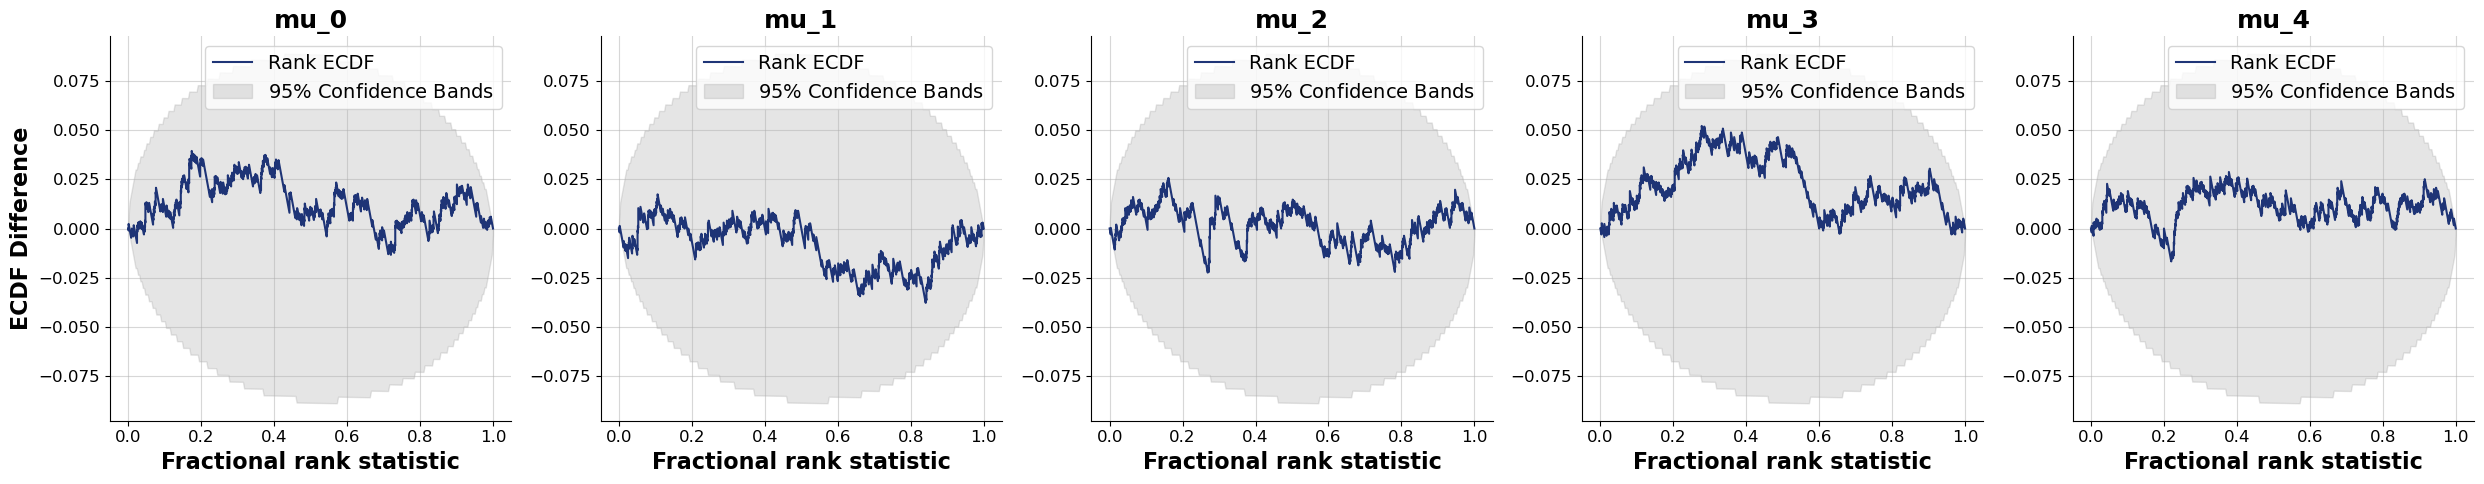

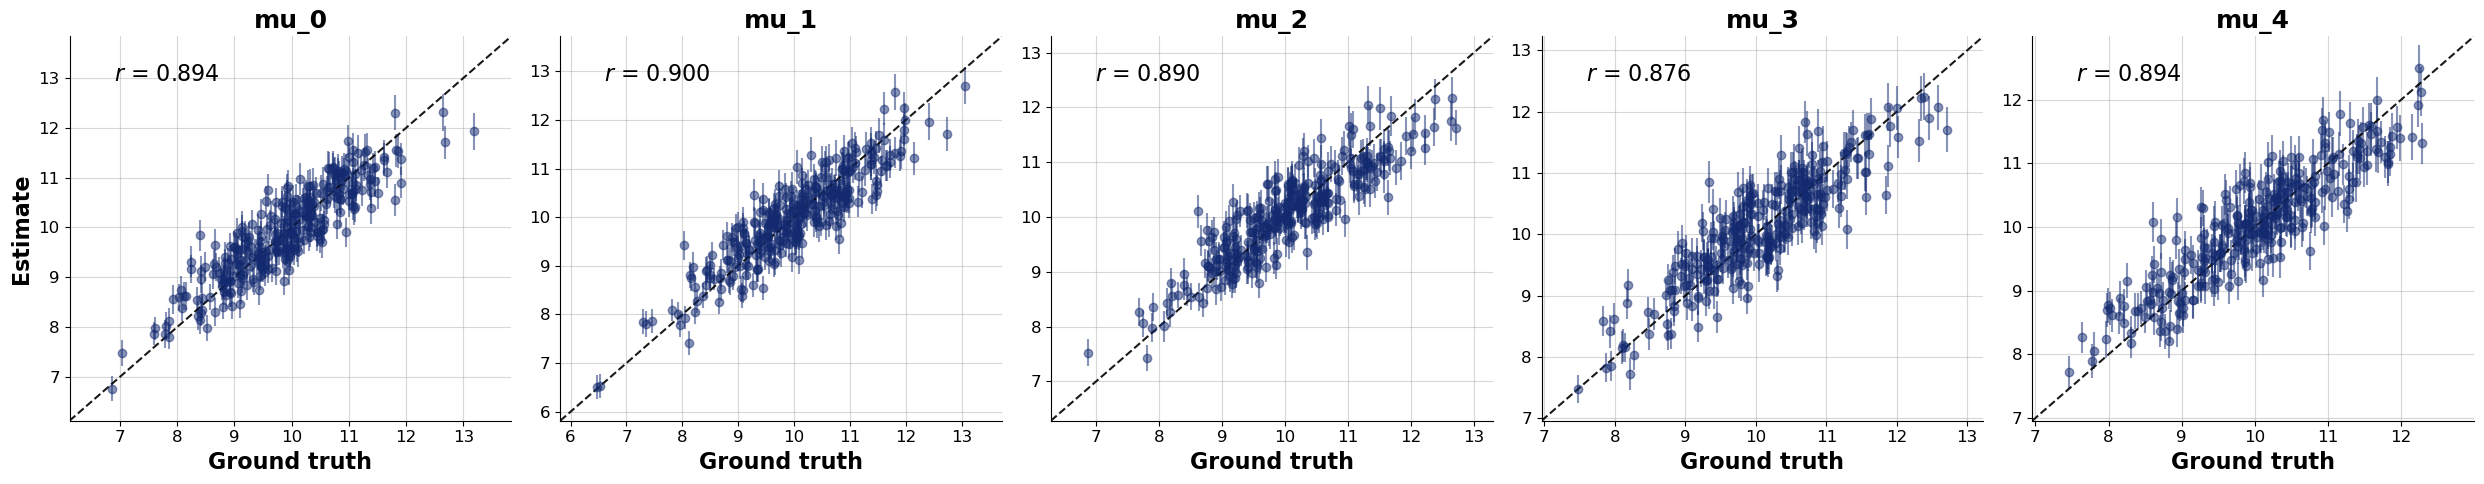

In [82]:
# Generate test datasets and get posterior samples and perform diagnostics
test_sims, posterior_samples = bayesflownpe.test_datasets(number_datasets=300, num_samples=1000)
f1 = bf.diagnostics.plots.calibration_histogram(posterior_samples, test_sims)
f2 = bf.diagnostics.plots.calibration_ecdf(posterior_samples, test_sims,difference=True)
f3 = bf.diagnostics.plots.recovery(posterior_samples, test_sims)

In [34]:
# Save the trained approximator
filepath = Path("/Users/mandyking/benchmark/benchmark/examples/gaussian/networks") / "npe_normal_prior_10.keras"
filepath.parent.mkdir(exist_ok=True)
bayesflownpe.workflow.approximator.save(filepath=filepath)

In [81]:
# Load the trained approximator
filepath = Path("/Users/mandyking/benchmark/benchmark/examples/gaussian/networks") / "npe_normal_prior_10.keras"
approximator=keras.saving.load_model(filepath)
simulator_bayes=Simulator(mu_prior_mean=mu_prior_mean, mu_prior_std=mu_prior_std, 
                                              num_dims=num_dims, num_obs=num_obs,likelihood_std=likelihood_std,rng=RNG)
simulator=simulator_bayes.get_bayes_simulator()
bayesflownpe=BayesFLowNPE(simulator=simulator)
bayesflownpe.workflow.approximator=approximator

In [35]:
# read datasets
def load_pickle(path: str):
    with open(path, "rb") as f:
        return pickle.load(f)

datasets_normal_0  = load_pickle("/Users/mandyking/benchmark/benchmark/examples/gaussian/results/datasets/01datasets_normal_0.pkl")
datasets_normal_10 = load_pickle("/Users/mandyking/benchmark/benchmark/examples/gaussian/results/datasets/01datasets_normal_10.pkl")
datasets_student   = load_pickle("/Users/mandyking/benchmark/benchmark/examples/gaussian/results/datasets/01datasets_student_df10.pkl")



In [36]:
calculation=Calculation(workflow=bayesflownpe,mu_prior_mean=mu_prior_mean, mu_prior_std=mu_prior_std,
                        num_dims=num_dims,num_obs=num_obs,
                 likelihood_std=likelihood_std,num_samples=1000)
datasets_normal_0=calculation.normal_analytical(obs_data=datasets_normal_0)
datasets_normal_0=calculation.npe_estimation(obs_data=datasets_normal_0)

datasets_normal_10=calculation.normal_analytical(obs_data=datasets_normal_10)
datasets_normal_10=calculation.npe_estimation(obs_data=datasets_normal_10)

datasets_student=calculation.normal_analytical(obs_data=datasets_student)
datasets_student=calculation.npe_estimation(obs_data=datasets_student)


In [37]:
# save datasetst
def save_pickle(obj, path: str):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "wb") as f:
        pickle.dump(obj, f)

save_pickle(datasets_normal_0,  "/Users/mandyking/benchmark/benchmark/examples/gaussian/results/datasets/02datasets_normal_0.pkl")
save_pickle(datasets_normal_10, "/Users/mandyking/benchmark/benchmark/examples/gaussian/results/datasets/02datasets_normal_10.pkl")
save_pickle(datasets_student,   "/Users/mandyking/benchmark/benchmark/examples/gaussian/results/datasets/02datasets_student_df10.pkl")

In [60]:
# calculate mmd and abs_error_lm for each type of datasets
group_specs = [
    (r"$M_1$", datasets_normal_0),   
    (r"$M_2$", datasets_normal_10),
    (r"$M_3$", datasets_student),   
]
metrics = pd.concat(
    [Analysis.evaluate_mmd_err(ds_list, name) for name, ds_list in group_specs],
    ignore_index=True
)


In [61]:
summary = (metrics
           .groupby("dataset_group")[["mmd", "abs_logml_error"]]
           .agg(["mean", "median", "std", "min", "max"])
           .reset_index())
print(summary)


  dataset_group       mmd                                          \
                     mean    median       std       min       max   
0         $M_1$  2.747249  2.652179  0.260957  2.428023  3.699800   
1         $M_2$  0.452997  0.365993  0.243360  0.211262  1.222853   
2         $M_3$  2.693827  2.642845  0.235755  2.302432  3.477588   

  abs_logml_error                                                           
             mean        median           std           min            max  
0    37384.947556  23216.175888  34528.467975  12706.296196  168327.641456  
1        0.111353      0.103758      0.094702      0.004770       0.418578  
2    30800.209052  23658.094225  21100.420788  10135.673299  117810.283700  


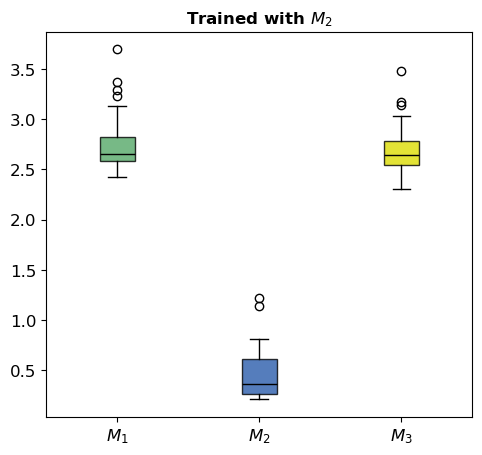

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.labelweight": "bold"
})

groups = [name for name, _ in group_specs]

data = []
for g in groups:
    s = metrics.loc[metrics["dataset_group"] == g, "mmd"]
    arr = pd.to_numeric(s, errors="coerce").dropna().astype(float).tolist()
    data.append(arr)

colors = ["#55A868","#2A5CAB", "#DDDD04",]

fig, ax = plt.subplots(figsize=(5.5, 5))

bp = ax.boxplot(
    data,
    tick_labels=groups,
    patch_artist=True,
    widths=0.25,
    medianprops=dict(color='black', linewidth=1)
)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)


ax.set_title(
    r"Trained with $M_2$",
    fontsize=12
)

plt.subplots_adjust(hspace=0.1)
plt.show()

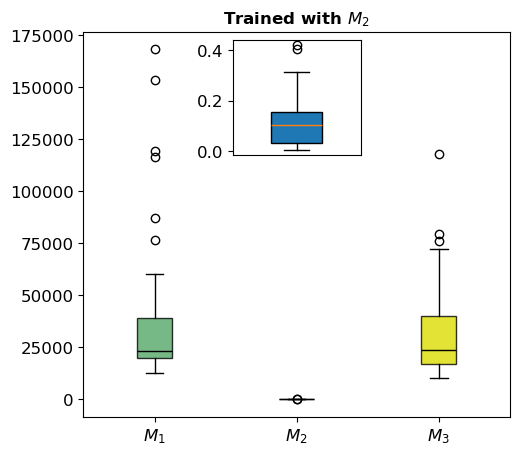

In [80]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
groups = [name for name, _ in group_specs]

data = []
for g in groups:
    s = metrics.loc[metrics["dataset_group"] == g, "abs_logml_error"]
    arr = pd.to_numeric(s, errors="coerce").dropna().astype(float).tolist()
    data.append(arr)

colors = ["#55A868","#2A5CAB", "#DDDD04",]

fig, ax = plt.subplots(figsize=(5.5, 5))

bp = ax.boxplot(
    data,
    tick_labels=groups,
    patch_artist=True,
    widths=0.25,
    medianprops=dict(color='black', linewidth=1)
)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)


ax.set_title(
    r"Trained with $M_2$",
    fontsize=12
)


axins = inset_axes(ax, width="30%", height="30%", loc="upper center")

axins.boxplot([data[1]], patch_artist=True, widths=0.4)

axins.set_xticks([])
plt.subplots_adjust(hspace=0.1)
plt.show()


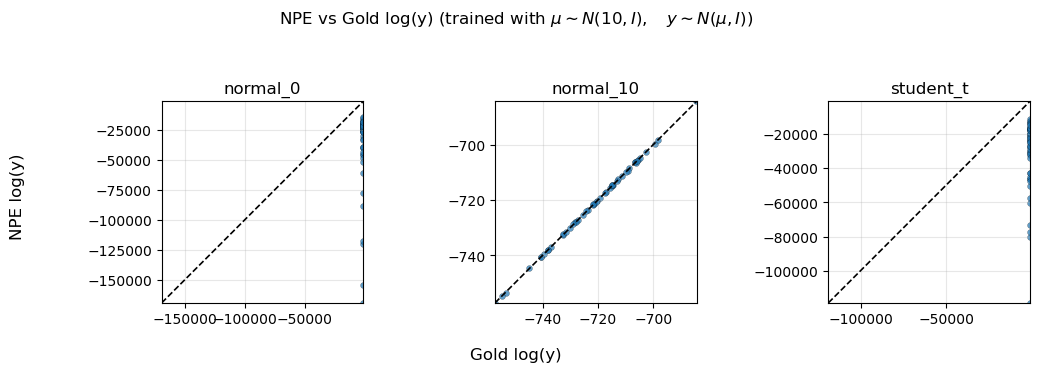

In [55]:
groups = [name for name, _ in group_specs]
xcol = "gold_logml"
ycol = "npe_logml"

fig, ax = plt.subplots(1, len(groups), figsize=(11, 3.6), sharey=False)

if len(groups) == 1:
    ax = [ax]

for i, g in enumerate(groups):
    sub = metrics.loc[metrics["dataset_group"] == g, [xcol, ycol]].dropna()
    x = sub[xcol].astype(float).to_numpy()
    y = sub[ycol].astype(float).to_numpy()
    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())
    ax[i].scatter(x, y, s=18, alpha=0.7, marker="o", edgecolors="k", linewidths=0.2)
    ax[i].plot([lo, hi], [lo, hi], linestyle="--", color="black", linewidth=1.2)
    ax[i].set_xlim(lo, hi)
    ax[i].set_ylim(lo, hi)
    ax[i].set_aspect("equal", adjustable="box")
    ax[i].grid(True, alpha=0.3)
    ax[i].set_title(g)
fig.supxlabel("Gold log(y)", y=0.04)
fig.supylabel("NPE log(y)", x=0.04)
fig.suptitle( r"NPE vs Gold log(y) (trained with $\mu \sim N(10, I), \quad y \sim N(\mu, I)$)", y=1.02)

plt.tight_layout(rect=[0.05, 0.05, 1, 0.92])
plt.show()